# Redes Neuronales Densas — Modelos de Forecasting

Objetivo: Entrenar modelos de redes neuronales con capas densas para predecir el promedio del log-return de cierre futuro de 23 activos del S&P 500, a través de 16 combinaciones de ventanas temporales de entrada y salida

Métrica: MAE

In [1]:
import os
import sys
sys.path.append('..')
os.chdir('..')

## 1. Importar y configuración

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, History

# Infraestructura compartida del proyecto
from src.data_pipeline import load_data, get_train_test, load_data_lopez_de_prado
from src.evaluation import compute_mae, save_results, count_parameters
from src.plotting import plot_training_curves
from config import INPUT_WINDOWS, OUTPUT_WINDOWS, FIGURES_DIR, MODELS_DIR

import os
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## 2. Carga de datos

In [3]:
returns = load_data()
returns_lp = load_data_lopez_de_prado(d=0.4, thres=1e-4)
print(f"\nShape: {returns.shape}")
print(f"Columnas: {list(returns.columns)}")
returns.head()
returns_lp.head()

[*********************100%***********************]  23 of 23 completed


Datos cargados: 16191 días, 23 activos
Rango: 1962-01-03 → 2026-05-04
Datos de López de Prado cargados: 15910 días, 23 activos (d=0.4)
Rango: 1963-02-13 → 2026-05-04

Shape: (16191, 23)
Columnas: ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1963-02-13,0.005198,-0.129733,-0.056603,-0.060277,-0.049378,-0.168541,-0.054450,-0.059826,-0.141133,-0.008846,...,-0.002916,-0.200134,-0.200797,-0.222412,-0.026212,-0.440504,-0.189559,-0.018530,-0.096355,-0.140500
1963-02-14,0.008723,-0.139052,-0.053189,-0.075232,-0.048656,-0.202792,-0.060980,-0.069356,-0.143752,-0.022178,...,0.000058,-0.196438,-0.201540,-0.228024,-0.024563,-0.443082,-0.164809,-0.018716,-0.102565,-0.143486
1963-02-15,-0.002541,-0.135111,-0.068034,-0.062017,-0.059528,-0.160561,-0.055045,-0.062801,-0.145240,-0.010046,...,0.007286,-0.197549,-0.201315,-0.220632,-0.027663,-0.458257,-0.170562,-0.025084,-0.104056,-0.143049
1963-02-18,-0.001207,-0.137201,-0.062584,-0.064274,-0.056152,-0.153365,-0.060605,-0.070730,-0.141931,-0.016613,...,0.004239,-0.194902,-0.196995,-0.235364,-0.039191,-0.458042,-0.178484,-0.028639,-0.098680,-0.138943
1963-02-19,0.002346,-0.151695,-0.067806,-0.073193,-0.055366,-0.167147,-0.052647,-0.080583,-0.135783,-0.032404,...,-0.004038,-0.198304,-0.200897,-0.233639,-0.047603,-0.477087,-0.179801,-0.027902,-0.112625,-0.142853


In [4]:
indice_comun = returns_lp.index
returns = returns.loc[indice_comun]
print(f"Index alineado correctamente. Tamaño: {len(returns)} días")

Index alineado correctamente. Tamaño: 15910 días


## 3. Entranamiento de modelos

In [5]:
from src.data_pipeline import create_time_series_data

INPUT_W = 5
OUTPUT_W = 90
# 3. Generar X a partir de LP e Y a partir de retornos_log
# Creamos las ventanas para X usando datos LP
X, _ = create_time_series_data(returns_lp, INPUT_W, OUTPUT_W)
# Creamos las ventanas para y usando datos estándar (d=1)
_, y = create_time_series_data(returns, INPUT_W, OUTPUT_W)
# 4. Hacer el split train/test idéntico
from sklearn.model_selection import train_test_split
from config import TEST_SIZE, RANDOM_SEED
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    shuffle=False,
    random_state=RANDOM_SEED
)
# Generar datos con ventanas y split (90% train / 10% test, cronológico)
#X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_W, OUTPUT_W)

print(f"\nInput shape:  X_train {X_train.shape} → (muestras, timesteps={INPUT_W}, activos=23)")
print(f"Output shape: y_train {y_train.shape} → (muestras, activos=23)")


Input shape:  X_train (14234, 5, 23) → (muestras, timesteps=5, activos=23)
Output shape: y_train (14234, 23) → (muestras, activos=23)


In [6]:
num_samples_train = X_train.shape[0]
num_samples_test = X_test.shape[0]

# Flatten X_train to (num_samples, input_window_size * num_features)
X_train_flat = X_train.reshape(num_samples_train, -1)
X_test_flat = X_test.reshape(num_samples_test, -1)

print(f"Shape of X_train_flat: {X_train_flat.shape}")
print(f"Shape of X_test_flat: {X_test_flat.shape}")

Shape of X_train_flat: (14234, 115)
Shape of X_test_flat: (1582, 115)


In [7]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.optimizers import Adam


model = Sequential([
        Input(shape=(X_train_flat.shape[1],)),
        Dense(4, activation='tanh'),
        Dense(100, activation='elu'),
        Dense(100, activation='elu'),
        Dense(y_train.shape[1], activation='linear') # Salida
    ])
    
model.compile(optimizer=Adam(learning_rate=1e-7), 
                  loss='mae', 
                  metrics=['mae'])


In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Configuras el Callback
early_stop = EarlyStopping(
    monitor='val_mae',         # Monitorea el MAE de validación
    patience=100,               # Si durante 100 épocas no mejora, detiene el entrenamiento
    restore_best_weights=True  # <-- ¡ESTA ES LA MAGIA! Restaura los mejores pesos automáticamente
)

# 2. Lo pasas dentro del fit
hist = model.fit(
    X_train_flat, y_train,
    epochs=2000,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop]     # <-- Añadimos el callback aquí
)

# ¡Listo! El objeto 'model' ahora tiene los pesos de la mejor época.
# Puedes hacer model.predict(X_test_scaled) directamente.

Epoch 1/2000
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 929us/step - loss: 0.0501 - mae: 0.0501 - val_loss: 0.0633 - val_mae: 0.0633
Epoch 2/2000
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - loss: 0.0494 - mae: 0.0494 - val_loss: 0.0623 - val_mae: 0.0623
Epoch 3/2000
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - loss: 0.0487 - mae: 0.0487 - val_loss: 0.0614 - val_mae: 0.0614
Epoch 4/2000
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - loss: 0.0480 - mae: 0.0480 - val_loss: 0.0605 - val_mae: 0.0605
Epoch 5/2000
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - loss: 0.0473 - mae: 0.0473 - val_loss: 0.0595 - val_mae: 0.0595
Epoch 6/2000
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.0466 - mae: 0.0466 - val_loss: 0.0586 - val_mae: 0.0586
Epoch 7/2000
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - loss: 0.0459 - mae: 0.0459 - val_loss: 0.0577 - val_mae: 0.0577
Epoch 8/2000
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - loss: 0.0452 - mae: 0.0452 - val_loss: 0.0568 - val_mae: 0.0568
Epoch 9/2000
401/401 ━━━

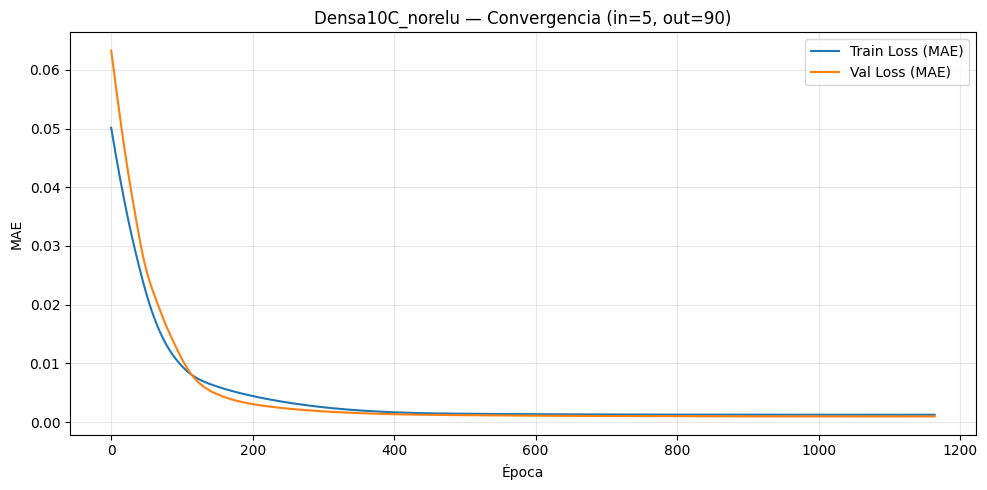

In [9]:
plot_training_curves(history=hist, model_name="Densa10C_norelu", 
 input_window=INPUT_W, 
 output_window=OUTPUT_W,
 save=False)

In [10]:
print("\n--- Model Layer Details (with Activations) ---")
for i, layer in enumerate(model.layers):
    config = layer.get_config()
    activation = config.get('activation', 'N/A')
    print(f"Layer {i+1}: {layer.name} | Units: {layer.units if hasattr(layer, 'units') else 'N/A'} | Activation: {activation}")
print("--------------------------------------------")


--- Model Layer Details (with Activations) ---
Layer 1: dense | Units: 4 | Activation: tanh
Layer 2: dense_1 | Units: 100 | Activation: elu
Layer 3: dense_2 | Units: 100 | Activation: elu
Layer 4: dense_3 | Units: 23 | Activation: linear
--------------------------------------------


In [13]:
from src.evaluation import compute_mae, save_results, count_parameters

# 1. Generar las predicciones del modelo
preds_train = model.predict(X_train_flat)
preds_test = model.predict(X_test_flat)

# 2. Calcular los MAE usando tu función común
mae_train = compute_mae(y_train, preds_train)
mae_test = compute_mae(y_test, preds_test)

# 3. Extraer el MAE de validación de la mejor época del entrenamiento
# (Manejamos si hist es diccionario o el objeto original de Keras)
hist_dict = hist.history if hasattr(hist, 'history') else hist
mae_val = min(hist_dict['val_mae']) if 'val_mae' in hist_dict else None

# 4. Contar los parámetros entrenables de tu red densa
n_params = count_parameters(model)

# 5. Guardar todo en el CSV centralizado ('all_results.csv')
save_results(
    model_name="Dense_LP(d=0.4)_lr(1e-7)_3C_tanh(4u)_elu(100u)_elu(100u)_(1165)_5_90",  # Nombre único descriptivo del modelo
    model_type="dense",          # Indica que es de capas densas
    input_window=INPUT_W,        # Ventana de entrada (ej: 30)
    output_window=OUTPUT_W,      # Ventana de salida (ej: 5)
    mae_train=mae_train,
    mae_val=mae_val,             # Añadimos la validación
    mae_test=mae_test,
    n_params=n_params
)


445/445 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step
Resultados guardados: Dense_LP(d=0.4)_lr(1e-7)_3C_tanh(4u)_elu(100u)_elu(100u)_(1165)_5_90 | in=5 out=90 | MAE test=0.001332


In [12]:
import pandas as pd

results_path = 'results/tables/all_results.csv'

if os.path.exists(results_path):
    all_results_df = pd.read_csv(results_path)
    # Sort by 'n_params' (number of parameters)
    all_results_df_sorted = all_results_df.sort_values(by='mae_val', ascending=True)
    print("Contenido de 'all_results.csv' ordenado por número de parámetros:")
    display(all_results_df_sorted)
else:
    print(f"El archivo {results_path} no fue encontrado.")

Contenido de 'all_results.csv' ordenado por número de parámetros:


,model_name,model_type,input_window,output_window,mae_train,mae_val,mae_test,n_params
34,Dense_3C_tanh(4u)_elu(100u)_elu(100u)_(421)_5_90,dense,5,90,0.001231,0.000926,0.001268,13387
40,Dense_3C_tanh(4u)_elu(100u)_elu(100u)_(169)_10_90,dense,10,90,0.001231,0.000927,0.001267,13847
31,Dense_3C_tanh(4u)_elu(100u)_elu(100u)_(159)_30_90,dense,30,90,0.001229,0.000930,0.001270,15687
41,Dense_3C_tanh(4u)_elu(100u)_elu(100u)_(140)_90_90,dense,90,90,0.001222,0.000930,0.001272,21207
32,Dense_3C_tanh(4u)_elu(100u)_elu(100u)_(1140)_3...,dense,30,30,0.002134,0.000930,0.002335,15687
39,Dense_LP(d=0.4)_3C_tanh(4u)_elu(100u)_elu(100u...,dense,5,90,0.001222,0.000955,0.001326,13387
42,Dense_LP(d=0.4)_lr(1e-7)_3C_tanh(4u)_elu(100u)...,dense,5,90,0.001214,0.000955,0.001332,13387
37,Dense_LP_3C_tanh(4u)_elu(100u)_elu(100u)_(158)...,dense,30,30,0.002112,0.001700,0.002385,15687
36,Dense_3C_tanh(4u)_elu(100u)_elu(100u)_(158)_30...,dense,30,30,0.002112,0.001700,0.002385,15687
35,Dense_3C_tanh(4u)_elu(100u)_elu(100u)_(571)_5_30,dense,5,30,0.002150,0.001702,0.002323,13387


In [50]:
model.save("notebooks/models/Dense_LP(d=0.4)_3C_tanh(4u)_elu(100u)_elu(100u)_(28)_5_90.keras")

## Keras Tuner

### 3.2 Modelo sencillo 

In [ ]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.optimizers import Adam


def crear_modelo_denso(num_caracteristicas, num_activos=23):
    """Crea una arquitectura MLP (Capa Densa) limpia"""
    model = Sequential([
        Input(shape=(num_caracteristicas,)),
        Dense(100, activation='relu'),
        Dense(num_activos, activation='linear') # Salida
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.0001), 
                  loss='mse', 
                  metrics=['mae'])
    return model

Model: "sequential_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_126 (Dense)               │ (None, 100)            │       207,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628,271 (2.40 MB)

 Trainable params: 209,423 (818.06 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 418,848 (1.60 MB)

In [18]:
from config import INPUT_WINDOWS, OUTPUT_WINDOWS
from src.data_pipeline import get_train_test

# Diccionario para guardar el historial de cada combinación
historias_entrenamiento = {}

for iw in INPUT_WINDOWS:
    for ow in OUTPUT_WINDOWS:
        print(f"\nEntrenando -> Entrada: {iw} días | Salida: {ow} días")
        
        # 1. Obtener datos
        X_train, X_test, y_train, y_test = get_train_test(returns, input_window=iw, output_window=ow)
        
        # 2. Aplanar (Flatten) porque es un modelo Denso
        X_train_flat = X_train.reshape(X_train.shape[0], -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        
        # 3. Crear modelo fresco
        num_caracteristicas = X_train_flat.shape[1]
        model = crear_modelo_denso(num_caracteristicas)
        
        # 4. Entrenar y guardar
        hist = model.fit(
            X_train_flat, y_train,
            epochs=200,             # Ajusta esto según necesites
            validation_split= 0.1,
            shuffle=True
        )
        
        # Guardamos la curva con una clave identificativa, ej: "In:30 Out:5"
        llave = f"In:{iw} Out:{ow}"
        historias_entrenamiento[llave] = hist.history



Entrenando -> Entrada: 5 días | Salida: 1 días
Ventana entrada=5, salida=1
  X_train: (14571, 5, 23) | y_train: (14571, 23)
  X_test:  (1620, 5, 23)  | y_test:  (1620, 23)
Epoch 1/200
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.8863e-04 - mae: 0.0138 - val_loss: 1.8497e-04 - val_mae: 0.0095
Epoch 2/200
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step - loss: 3.2694e-04 - mae: 0.0124 - val_loss: 1.7458e-04 - val_mae: 0.0092
Epoch 3/200
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step - loss: 3.1267e-04 - mae: 0.0121 - val_loss: 1.7182e-04 - val_mae: 0.0091
Epoch 4/200
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - loss: 3.0688e-04 - mae: 0.0120 - val_loss: 1.7080e-04 - val_mae: 0.0090
Epoch 5/200
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.0371e-04 - mae: 0.0119 - val_loss: 1.7036e-04 - val_mae: 0.0090
Epoch 6/200
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.0162e-04 - mae: 0.0119 - val_loss: 1.7018e-04 - val_mae: 0.0090
Epoch 7/200
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss

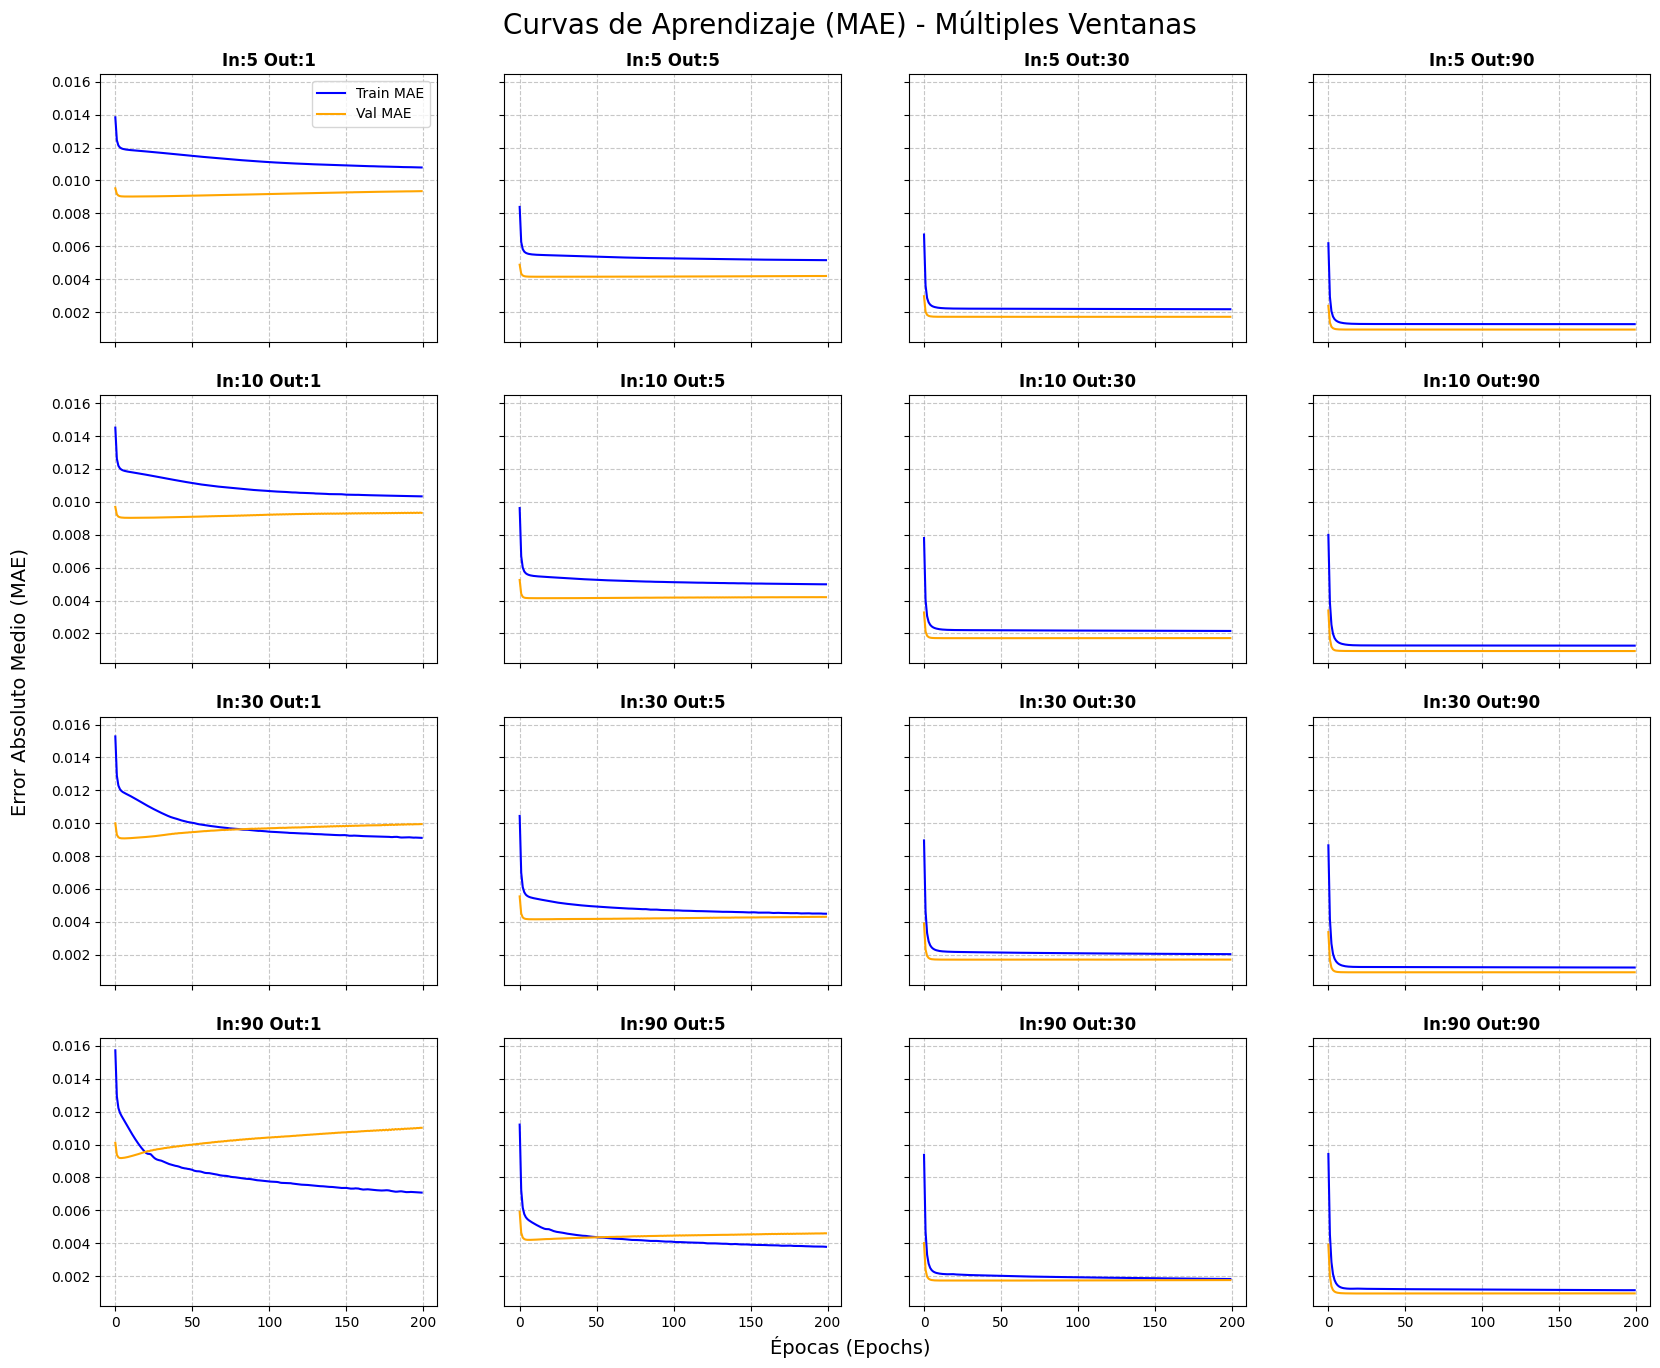

In [19]:
# Crear una matriz de gráficas 4x4
fig, axes = plt.subplots(nrows=len(INPUT_WINDOWS), 
                         ncols=len(OUTPUT_WINDOWS), 
                         figsize=(20, 16), 
                         sharex=True, 
                         sharey=True) # sharey=True para poder comparar las escalas visualmente

# Título global
fig.suptitle("Curvas de Aprendizaje (MAE) - Múltiples Ventanas", fontsize=20, y=0.92)

for i, iw in enumerate(INPUT_WINDOWS):
    for j, ow in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]
        llave = f"In:{iw} Out:{ow}"
        historia = historias_entrenamiento[llave]
        
        # Dibujar líneas de Entrenamiento y Validación
        ax.plot(historia['mae'], label='Train MAE', color='blue')
        ax.plot(historia['val_mae'], label='Val MAE', color='orange')
        
        # Títulos y estilos para cada subgráfica
        ax.set_title(llave, fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Poner leyendas solo en la primera para no recargar visualmente
        if i == 0 and j == 0:
            ax.legend()

# Etiquetas de los ejes principales
fig.text(0.5, 0.08, 'Épocas (Epochs)', ha='center', fontsize=14)
fig.text(0.08, 0.5, 'Error Absoluto Medio (MAE)', va='center', rotation='vertical', fontsize=14)

plt.show()


In [24]:
model.summary()

Model: "sequential_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_126 (Dense)               │ (None, 100)            │       207,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628,271 (2.40 MB)

 Trainable params: 209,423 (818.06 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 418,848 (1.60 MB)

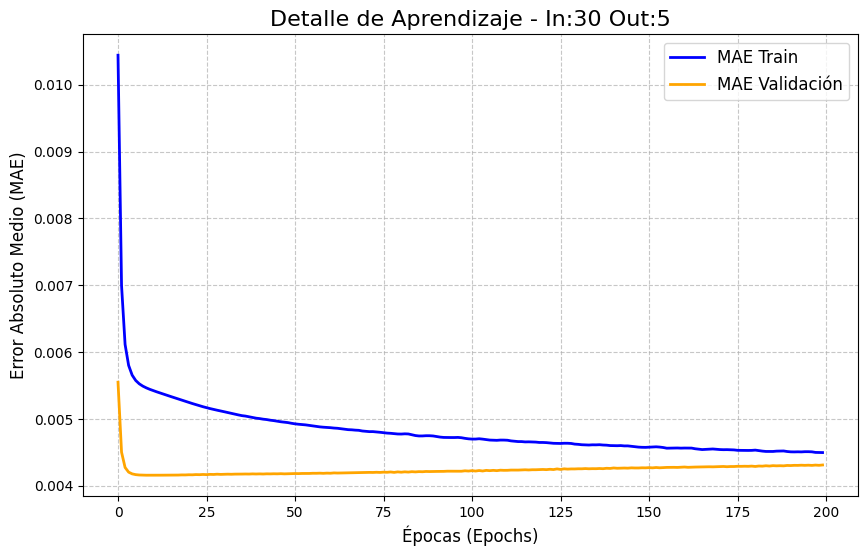

In [34]:
# Elige la combinación que quieras ver en detalle
llave_detalle = "In:30 Out:5"

# Extraemos solo su historial
historia_individual = historias_entrenamiento[llave_detalle]

# Dibujamos la gráfica en tamaño grande
plt.figure(figsize=(10, 6))

plt.plot(historia_individual['mae'], label='MAE Train', color='blue', linewidth=2)
plt.plot(historia_individual['val_mae'], label='MAE Validación', color='orange', linewidth=2)

plt.title(f'Detalle de Aprendizaje - {llave_detalle}', fontsize=16)
plt.xlabel('Épocas (Epochs)', fontsize=12)
plt.ylabel('Error Absoluto Medio (MAE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Opcional: limitar el eje Y si el primer pico distorsiona mucho la gráfica
# plt.ylim(0, 0.05) 

plt.show()


In [ ]:
#Probar en test

## 3.3 Añadimos capas
Viendo los gráficos ninguna curva parece funcionar solo con una capa. Vamos a definir otro modelo con más capas. En este caso añadiremos dos capas reduciendo el número de neuronas en cada uno. Además, rebajamos el learning rate y aumentamos los entrenamientos a 500

In [28]:
def crear_modelo_denso_capas3(num_caracteristicas, num_activos=23):
    """Crea una arquitectura MLP (Capa Densa) limpia"""
    model = Sequential([
        Input(shape=(num_caracteristicas,)),
        Dense(100, activation='relu'),
        Dense(80, activation='relu'),
        Dense(60, activation='relu'),
        Dense(num_activos, activation='linear') # Salida
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.0001), 
                  loss='mse', 
                  metrics=['mae'])
    return model

In [29]:
# Diccionario para guardar el historial de cada combinación
historias_entrenamiento_capas3 = {}

for iw in INPUT_WINDOWS:
    for ow in OUTPUT_WINDOWS:
        print(f"\nEntrenando -> Entrada: {iw} días | Salida: {ow} días")
        
        # 1. Obtener datos
        X_train, X_test, y_train, y_test = get_train_test(returns, input_window=iw, output_window=ow)
        
        # 2. Aplanar (Flatten) porque es un modelo Denso
        X_train_flat = X_train.reshape(X_train.shape[0], -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        
        # 3. Crear modelo fresco
        num_caracteristicas = X_train_flat.shape[1]
        model = crear_modelo_denso_capas3(num_caracteristicas)
        
        # 4. Entrenar y guardar
        hist = model.fit(
            X_train_flat, y_train,
            epochs=500,             # Ajusta esto según necesites
            validation_split= 0.1,
            shuffle=True
        )
        
        # Guardamos la curva con una clave identificativa, ej: "In:30 Out:5"
        llave_capas3 = f"In:{iw} Out:{ow}"
        historias_entrenamiento_capas3[llave_capas3] = hist.history



Entrenando -> Entrada: 5 días | Salida: 1 días
Ventana entrada=5, salida=1
  X_train: (14571, 5, 23) | y_train: (14571, 23)
  X_test:  (1620, 5, 23)  | y_test:  (1620, 23)
Epoch 1/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - loss: 3.0963e-04 - mae: 0.0121 - val_loss: 1.7011e-04 - val_mae: 0.0090
Epoch 2/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step - loss: 3.0107e-04 - mae: 0.0119 - val_loss: 1.7001e-04 - val_mae: 0.0090
Epoch 3/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 3.0002e-04 - mae: 0.0119 - val_loss: 1.7001e-04 - val_mae: 0.0090
Epoch 4/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 2.9935e-04 - mae: 0.0119 - val_loss: 1.7003e-04 - val_mae: 0.0090
Epoch 5/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - loss: 2.9875e-04 - mae: 0.0118 - val_loss: 1.7005e-04 - val_mae: 0.0090
Epoch 6/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - loss: 2.9810e-04 - mae: 0.0118 - val_loss: 1.7009e-04 - val_mae: 0.0090
Epoch 7/500
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/ste

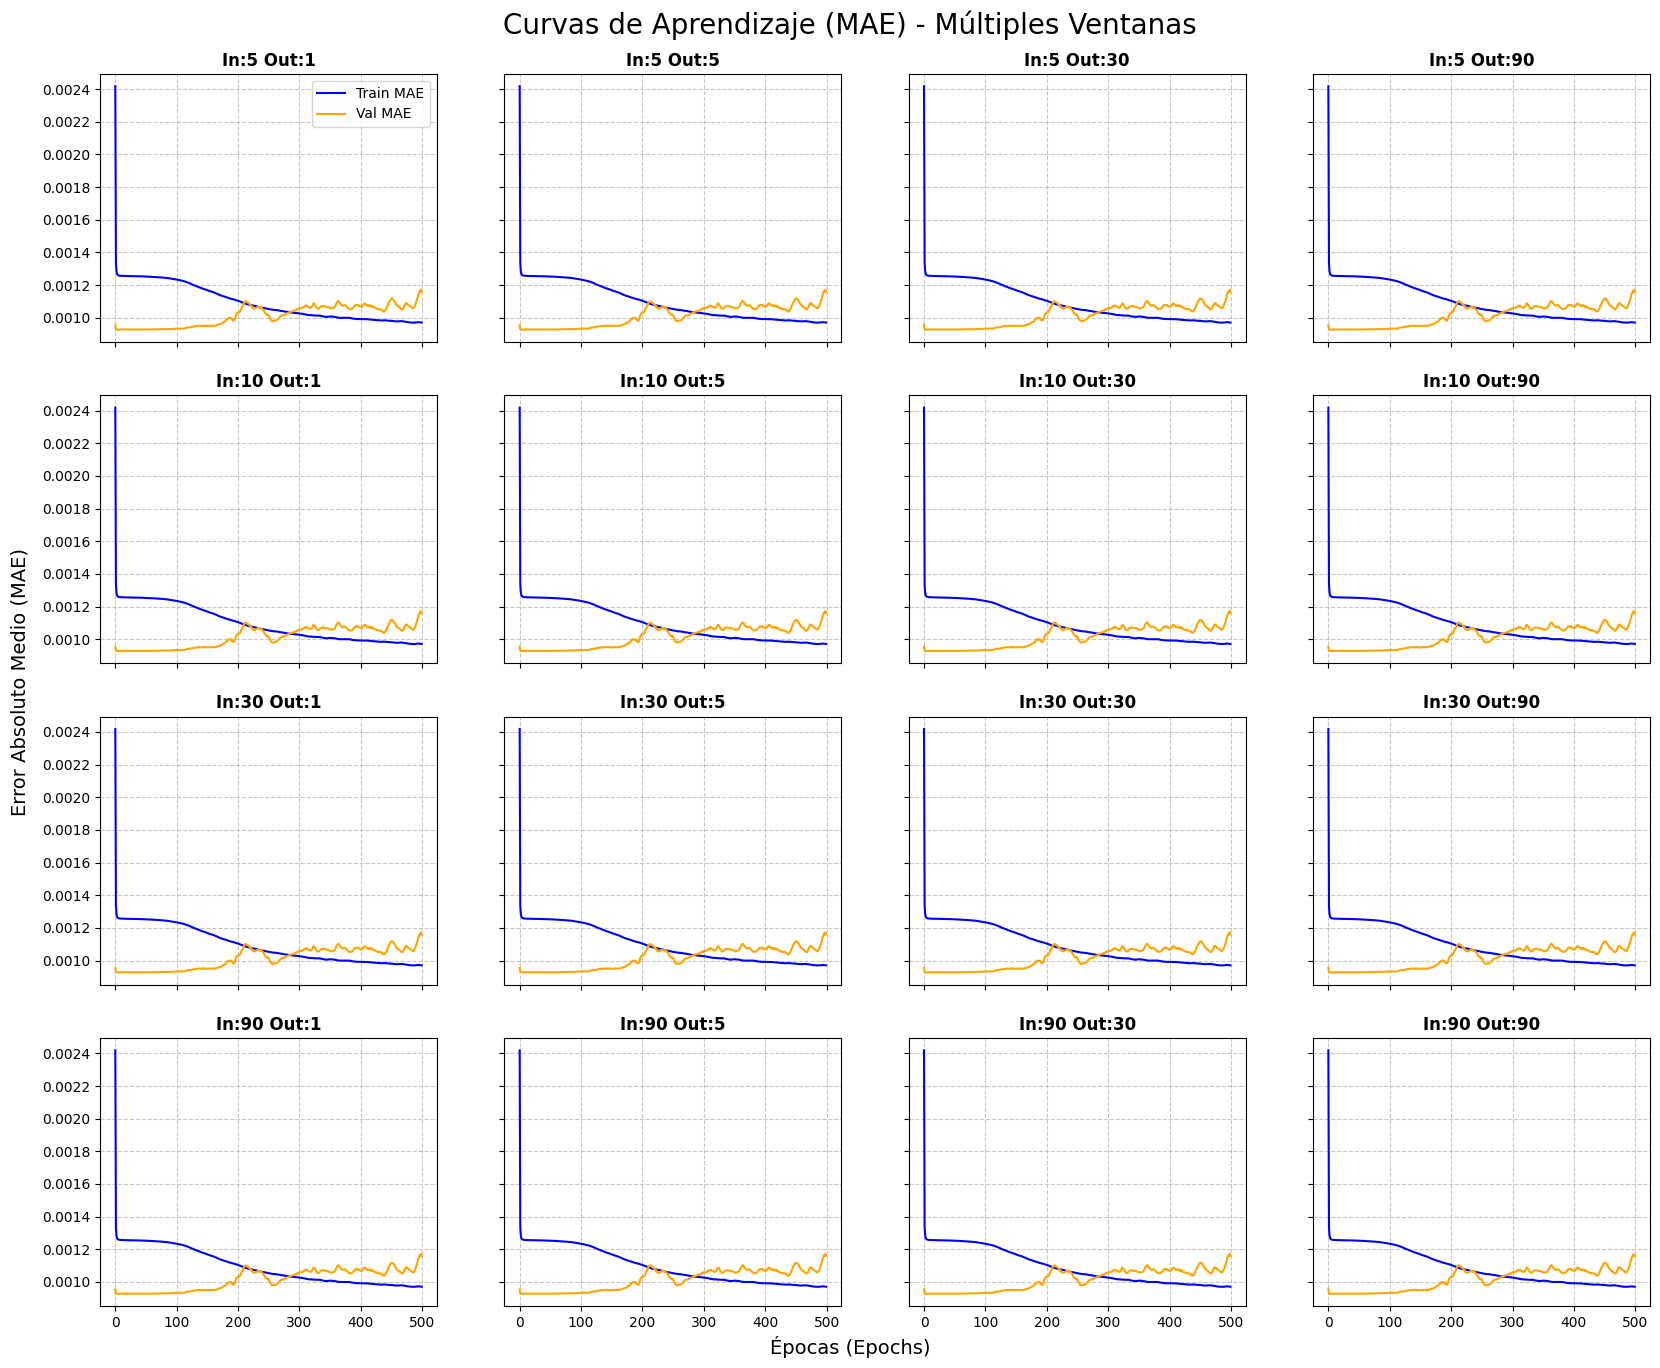

In [30]:
# Crear una matriz de gráficas 4x4
fig, axes = plt.subplots(nrows=len(INPUT_WINDOWS), 
                         ncols=len(OUTPUT_WINDOWS), 
                         figsize=(20, 16), 
                         sharex=True, 
                         sharey=True) # sharey=True para poder comparar las escalas visualmente

# Título global
fig.suptitle("Curvas de Aprendizaje (MAE) - Múltiples Ventanas", fontsize=20, y=0.92)

for i, iw in enumerate(INPUT_WINDOWS):
    for j, ow in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]
        llave = f"In:{iw} Out:{ow}"
        historia = historias_entrenamiento_capas3[llave_capas3]
        
        # Dibujar líneas de Entrenamiento y Validación
        ax.plot(historia['mae'], label='Train MAE', color='blue')
        ax.plot(historia['val_mae'], label='Val MAE', color='orange')
        
        # Títulos y estilos para cada subgráfica
        ax.set_title(llave, fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Poner leyendas solo en la primera para no recargar visualmente
        if i == 0 and j == 0:
            ax.legend()

# Etiquetas de los ejes principales
fig.text(0.5, 0.08, 'Épocas (Epochs)', ha='center', fontsize=14)
fig.text(0.08, 0.5, 'Error Absoluto Medio (MAE)', va='center', rotation='vertical', fontsize=14)

plt.show()


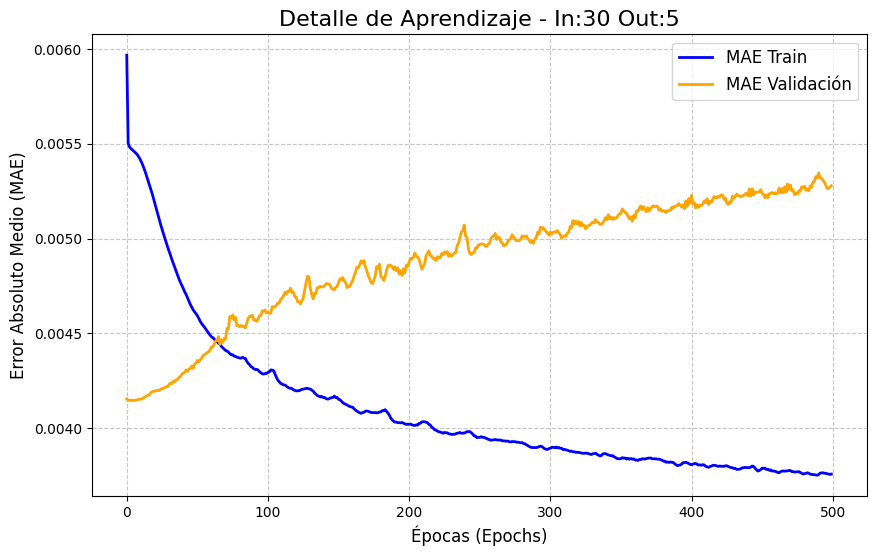

In [33]:
# Elige la combinación que quieras ver en detalle
llave_detalle = "In:30 Out:5"

# Extraemos solo su historial
historia_individual = historias_entrenamiento_capas3[llave_detalle]

# Dibujamos la gráfica en tamaño grande
plt.figure(figsize=(10, 6))

plt.plot(historia_individual['mae'], label='MAE Train', color='blue', linewidth=2)
plt.plot(historia_individual['val_mae'], label='MAE Validación', color='orange', linewidth=2)

plt.title(f'Detalle de Aprendizaje - {llave_detalle}', fontsize=16)
plt.xlabel('Épocas (Epochs)', fontsize=12)
plt.ylabel('Error Absoluto Medio (MAE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Opcional: limitar el eje Y si el primer pico distorsiona mucho la gráfica
# plt.ylim(0, 0.05) 

plt.show()


In [32]:
model.summary()

Model: "sequential_63"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_188 (Dense)               │ (None, 100)            │       207,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_189 (Dense)               │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_190 (Dense)               │ (None, 60)             │         4,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_191 (Dense)               │ (None, 23)             │         1,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,331 (2.53 MB)

 Trainable params: 221,443 (865.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 442,888 (1.69 MB)